# O1 7,500-trial fixed-depth analytics

This notebook analyzes the fixed random-forest depths 5, 10, 15, 20, and 25 from `01_initial`. The experiment contains two O1 benchmark seeds and five SMAC seeds per depth, with 7,500 trials, 50 dimensions, 100 instances, leaf/split sizes of 1, and a 10% random-design probability.

All performance values below are incumbent regret, so **lower is better**. In addition to final performance, the notebook examines improvement activity in 500-trial blocks. Those block-level signals are useful when designing a future runtime-adaptive depth policy.

## Setup

The analysis constants mirror the submitted experiment. Path discovery works when Jupyter is started either from the repository root or from this experiment directory.

In [1]:
from __future__ import annotations

import json
from itertools import product
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.stats import t

DEPTHS = (5, 10, 15, 20, 25)
BENCHMARK_SEEDS = (40, 41)
SMAC_SEEDS = tuple(range(5))
N_TRIALS = 7_500
N_INSTANCES = 100
DIMENSION = 50
CHECKPOINTS = (500, 1_000, 2_500, 5_000, 7_500)
BLOCK_SIZE = 500
BLOCK_ENDS = tuple(range(BLOCK_SIZE, N_TRIALS + 1, BLOCK_SIZE))

relative_experiment_path = Path(
    "experiments/synthaticBench/o1_deterministic/7500_depth_policies"
)
search_roots = (Path.cwd(), *Path.cwd().parents)
candidates = [Path.cwd(), *(root / relative_experiment_path for root in search_roots)]
HERE = next(
    (path for path in candidates if (path / "01_initial/o1_7500_depth_runner.py").exists()),
    None,
)
if HERE is None:
    raise FileNotFoundError(
        "Could not locate 7500_depth_policies. Start Jupyter from the repository "
        "root or from this experiment directory."
    )

OUTPUT = HERE / "01_initial/smac_output"
COLORS = dict(zip(DEPTHS, plt.cm.viridis(np.linspace(0.08, 0.92, len(DEPTHS)))))
print(f"Experiment directory: {HERE.resolve()}")
print(f"Trajectory directory: {OUTPUT.resolve()}")

Experiment directory: /rwthfs/rz/cluster/home/io632776/experiments/adaptive-smac/experiments/synthaticBench/o1_deterministic/7500_depth_policies
Trajectory directory: /rwthfs/rz/cluster/home/io632776/experiments/adaptive-smac/experiments/synthaticBench/o1_deterministic/7500_depth_policies/01_initial/smac_output


## Load and validate trajectories

The coverage table reports the number of distinct SMAC seeds found for every benchmark-seed/depth combination. A complete experiment has five in every cell and 50 trajectories in total. The loader also rejects duplicate runs, incomplete trajectories, non-monotone incumbent curves, unexpected metadata, and inconsistent instance maps so that incomplete or incompatible results cannot silently enter the analysis.

In [2]:
expected_runs = set(product(BENCHMARK_SEEDS, DEPTHS, SMAC_SEEDS))
curves: dict[tuple[int, int, int], np.ndarray] = {}
rows: list[dict[str, float | int]] = []
instance_maps: set[str] = set()

trajectory_paths = sorted(OUTPUT.rglob("trajectory.json")) if OUTPUT.exists() else []
if not trajectory_paths:
    raise FileNotFoundError(
        f"No trajectory.json files found below {OUTPUT}. "
        "Wait for at least one Submitit job to finish before running the analysis."
    )

for path in trajectory_paths:
    data = json.loads(path.read_text())
    benchmark_seed = int(data["benchmark_seed"])
    depth = int(data["max_depth"])
    smac_seed = int(data["smac_seed"])
    key = (benchmark_seed, depth, smac_seed)
    if key in curves:
        raise ValueError(f"Duplicate trajectory for {key}: {path}")

    expected_metadata = {
        "problem": "O1-DeterministicObjective",
        "policy": f"fixed_depth_{depth}",
        "policy_type": "fixed_depth",
        "dimension": DIMENSION,
        "n_instances": N_INSTANCES,
        "n_trials": N_TRIALS,
        "min_samples_leaf": 1,
        "min_samples_split": 1,
        "pythonhashseed": "12345",
    }
    mismatches = {
        field: (data.get(field), expected)
        for field, expected in expected_metadata.items()
        if data.get(field) != expected
    }
    if not np.isclose(float(data.get("random_design_probability", np.nan)), 0.10):
        mismatches["random_design_probability"] = (
            data.get("random_design_probability"),
            0.10,
        )
    if mismatches:
        raise ValueError(f"Metadata mismatch in {path}: {mismatches}")

    best_regret = np.asarray(data["best_regret"], dtype=float)
    if best_regret.shape != (N_TRIALS,):
        raise ValueError(f"Expected {N_TRIALS} regrets in {path}, got {best_regret.shape}.")
    if not np.all(np.isfinite(best_regret)):
        raise ValueError(f"Non-finite incumbent regret in {path}.")
    if np.any(best_regret < -1e-10):
        raise ValueError(f"Negative incumbent regret in {path}.")
    if np.any(np.diff(best_regret) > 1e-12):
        raise ValueError(f"Incumbent regret is not monotone in {path}.")

    curves[key] = best_regret
    instance_maps.add(json.dumps(data["instance_map"], sort_keys=True))
    rows.append(
        {
            "benchmark_seed": benchmark_seed,
            "depth": depth,
            "smac_seed": smac_seed,
            "final_regret": float(best_regret[-1]),
            "mean_regret": float(best_regret.mean()),
        }
    )

if len(instance_maps) != 1:
    raise ValueError(f"Expected one shared instance map, found {len(instance_maps)}.")

found_runs = set(curves)
missing_runs = sorted(expected_runs - found_runs)
unexpected_runs = sorted(found_runs - expected_runs)
if missing_runs or unexpected_runs:
    raise ValueError(
        f"Experiment coverage is incomplete. Missing ({len(missing_runs)}): {missing_runs}; "
        f"unexpected ({len(unexpected_runs)}): {unexpected_runs}."
    )

results = pd.DataFrame(rows).sort_values(
    ["benchmark_seed", "depth", "smac_seed"]
).reset_index(drop=True)
positive_regrets = np.concatenate(list(curves.values()))
positive_regrets = positive_regrets[positive_regrets > 0]
REGRET_FLOOR = max(float(positive_regrets.min()) / 10, 1e-300)
results["mean_log10_regret"] = [
    float(np.log10(np.maximum(curves[key], REGRET_FLOOR)).mean())
    for key in zip(results["benchmark_seed"], results["depth"], results["smac_seed"])
]

coverage = (
    results.groupby(["benchmark_seed", "depth"])["smac_seed"]
    .nunique()
    .unstack("depth")
    .reindex(index=BENCHMARK_SEEDS, columns=DEPTHS, fill_value=0)
)
display(coverage.style.set_caption("Distinct SMAC seeds per benchmark seed and depth"))
print(f"Validated {len(results)} trajectories; log-plot floor = {REGRET_FLOOR:.3e}.")

depth,5,10,15,20,25
benchmark_seed,,,,,
40,5,5,5,5,5
41,5,5,5,5,5


Validated 50 trajectories; log-plot floor = 1.126e+04.


## Incumbent trajectories by benchmark seed

Each panel holds the O1 landscape fixed and compares depths across the five SMAC seeds. Solid lines are mean incumbent regret and shaded bands are pointwise 95% Student-*t* confidence intervals. The logarithmic regret axis makes late improvements visible; values at zero are clipped only for plotting. Narrow intervals indicate agreement among SMAC seeds, while overlap should not be interpreted as a formal hypothesis test.

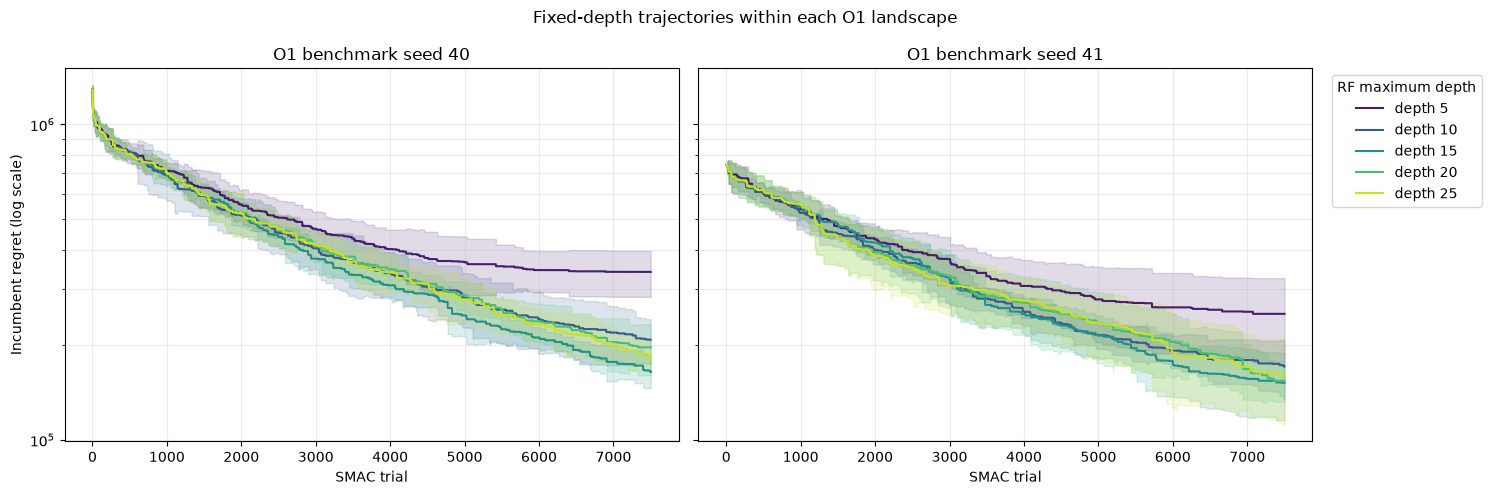

In [3]:
def mean_and_ci(matrix: np.ndarray, confidence: float = 0.95) -> tuple[np.ndarray, np.ndarray]:
    mean = matrix.mean(axis=0)
    if matrix.shape[0] < 2:
        return mean, np.zeros_like(mean)
    sem = matrix.std(axis=0, ddof=1) / np.sqrt(matrix.shape[0])
    margin = t.ppf((1 + confidence) / 2, df=matrix.shape[0] - 1) * sem
    return mean, margin

def plot_values(values: np.ndarray) -> np.ndarray:
    return np.maximum(values, REGRET_FLOOR)

iterations = np.arange(1, N_TRIALS + 1)
fig, axes = plt.subplots(1, len(BENCHMARK_SEEDS), figsize=(15, 5), sharex=True, sharey=True)
for axis, benchmark_seed in zip(axes, BENCHMARK_SEEDS):
    for depth in DEPTHS:
        matrix = np.stack([curves[(benchmark_seed, depth, seed)] for seed in SMAC_SEEDS])
        mean, margin = mean_and_ci(matrix)
        axis.plot(iterations, plot_values(mean), color=COLORS[depth], label=f"depth {depth}")
        axis.fill_between(
            iterations,
            plot_values(mean - margin),
            plot_values(mean + margin),
            color=COLORS[depth],
            alpha=0.16,
        )
    axis.set_title(f"O1 benchmark seed {benchmark_seed}")
    axis.set_xlabel("SMAC trial")
    axis.set_yscale("log")
    axis.grid(alpha=0.25, which="both")
axes[0].set_ylabel("Incumbent regret (log scale)")
axes[-1].legend(title="RF maximum depth", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.suptitle("Fixed-depth trajectories within each O1 landscape")
fig.tight_layout()
plt.show()

## Pooled incumbent trajectories

This plot pools the ten benchmark-seed/SMAC-seed runs available for each depth. It gives one compact descriptive comparison of the depth policies. Because there are only two independently seeded O1 landscapes, the confidence bands mainly summarize variation within this experiment and should not be treated as broad benchmark-generalization intervals.

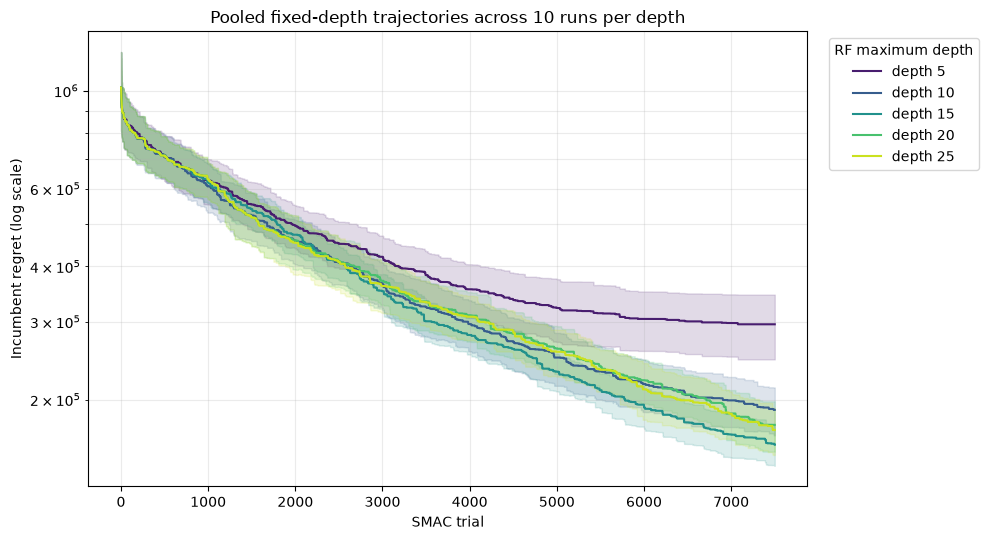

In [4]:
fig, axis = plt.subplots(figsize=(10, 5.5))
for depth in DEPTHS:
    matrix = np.stack(
        [curves[(benchmark_seed, depth, smac_seed)] for benchmark_seed in BENCHMARK_SEEDS for smac_seed in SMAC_SEEDS]
    )
    mean, margin = mean_and_ci(matrix)
    axis.plot(iterations, plot_values(mean), color=COLORS[depth], label=f"depth {depth}")
    axis.fill_between(
        iterations,
        plot_values(mean - margin),
        plot_values(mean + margin),
        color=COLORS[depth],
        alpha=0.16,
    )
axis.set(
    title="Pooled fixed-depth trajectories across 10 runs per depth",
    xlabel="SMAC trial",
    ylabel="Incumbent regret (log scale)",
)
axis.set_yscale("log")
axis.grid(alpha=0.25, which="both")
axis.legend(title="RF maximum depth", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
plt.show()

## Performance at selected checkpoints

Each box contains the ten paired runs for one depth at the indicated trial. The overlaid dots expose every observation instead of hiding the small sample behind summary statistics. Reading the panels from left to right shows whether the preferred depth changes over the optimization horizon. The regret axis is logarithmic and lower is better.

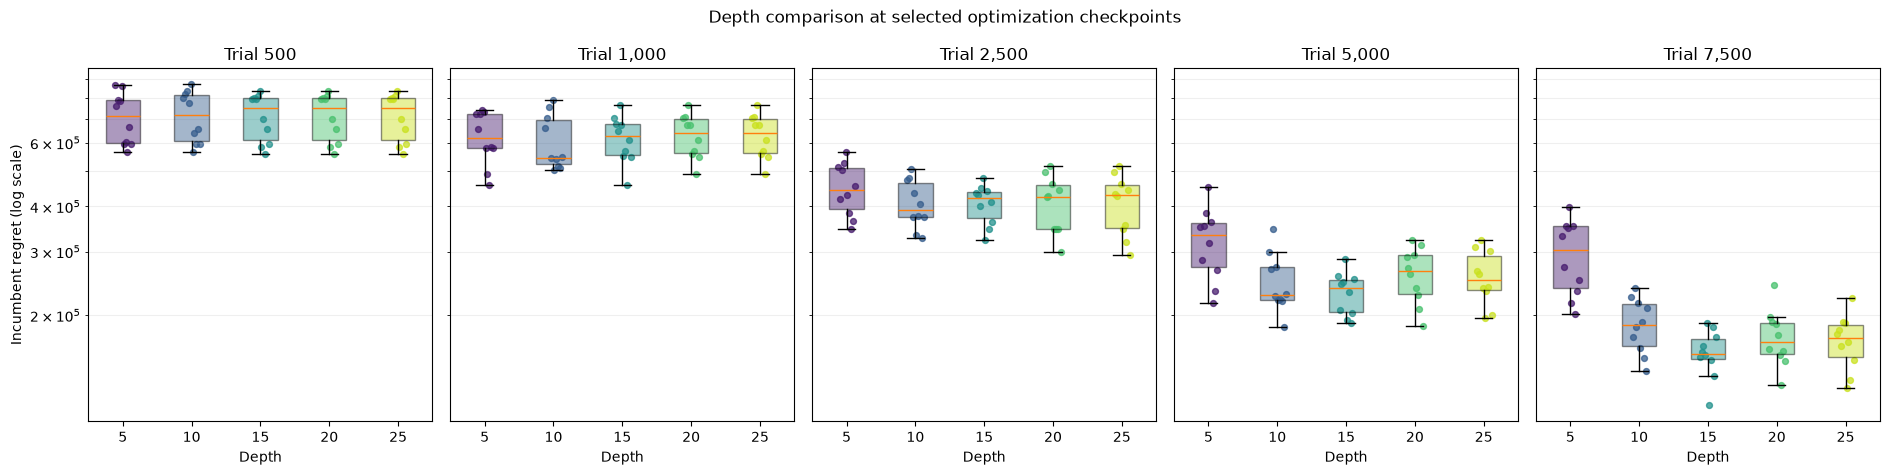

In [5]:
fig, axes = plt.subplots(1, len(CHECKPOINTS), figsize=(19, 4.8), sharey=True)
for axis, checkpoint in zip(axes, CHECKPOINTS):
    values = [
        [
            max(curves[(benchmark_seed, depth, smac_seed)][checkpoint - 1], REGRET_FLOOR)
            for benchmark_seed in BENCHMARK_SEEDS
            for smac_seed in SMAC_SEEDS
        ]
        for depth in DEPTHS
    ]
    boxes = axis.boxplot(values, patch_artist=True, showfliers=False)
    for patch, depth in zip(boxes["boxes"], DEPTHS):
        patch.set_facecolor(COLORS[depth])
        patch.set_alpha(0.45)
    for position, (depth, depth_values) in enumerate(zip(DEPTHS, values), start=1):
        jitter = np.linspace(-0.12, 0.12, len(depth_values))
        axis.scatter(position + jitter, depth_values, color=COLORS[depth], s=18, alpha=0.75)
    axis.set_title(f"Trial {checkpoint:,}")
    axis.set_xlabel("Depth")
    axis.set_xticks(range(1, len(DEPTHS) + 1), DEPTHS)
    axis.set_yscale("log")
    axis.grid(alpha=0.2, axis="y", which="both")
axes[0].set_ylabel("Incumbent regret (log scale)")
fig.suptitle("Depth comparison at selected optimization checkpoints")
fig.tight_layout()
plt.show()

## Numerical performance summaries

The first table keeps the two O1 benchmark seeds separate; the second pools them. `final_regret` measures the endpoint, `mean_regret` rewards strong incumbents throughout the complete run, and `mean_log10_regret` is the average log-regret over all 7,500 trials. Lower values are better for every metric. Standard deviations describe run-to-run variability, while medians reduce the influence of unusually easy or difficult runs.

In [6]:
by_landscape = (
    results.groupby(["benchmark_seed", "depth"])
    .agg(
        runs=("smac_seed", "size"),
        final_mean=("final_regret", "mean"),
        final_std=("final_regret", "std"),
        final_median=("final_regret", "median"),
        trajectory_mean=("mean_regret", "mean"),
        log_trajectory_mean=("mean_log10_regret", "mean"),
    )
    .reset_index()
)
pooled = (
    results.groupby("depth")
    .agg(
        runs=("smac_seed", "size"),
        final_mean=("final_regret", "mean"),
        final_std=("final_regret", "std"),
        final_median=("final_regret", "median"),
        trajectory_mean=("mean_regret", "mean"),
        log_trajectory_mean=("mean_log10_regret", "mean"),
    )
    .reset_index()
)
display(by_landscape.style.format(precision=4).set_caption("Performance by O1 benchmark seed"))
display(pooled.style.format(precision=4).set_caption("Performance pooled across both O1 benchmark seeds"))

,benchmark_seed,depth,runs,final_mean,final_std,final_median,trajectory_mean,log_trajectory_mean
0,40,5,5,340898.3685,45627.8447,347650.1172,488475.4793,5.6637
1,40,10,5,207862.0541,27220.9542,216432.2402,419137.9078,5.5742
2,40,15,5,164060.9271,15026.8285,158048.9123,399798.2731,5.5426
3,40,20,5,196488.1468,29262.1999,191561.9445,421866.6465,5.5770
4,40,25,5,181171.0857,11097.0516,182391.8702,418062.9244,5.5706
5,41,5,5,251023.3664,60196.4685,232769.4051,370806.9731,5.5432
6,41,10,5,171064.5375,28909.8605,161948.2819,323630.4616,5.4682
7,41,15,5,151893.8907,29373.5129,150829.6011,322365.2951,5.4564
8,41,20,5,154019.1177,17512.0882,155445.9111,327964.0234,5.4731
9,41,25,5,160102.6112,38795.4575,149977.7754,326438.8352,5.4699


,depth,runs,final_mean,final_std,final_median,trajectory_mean,log_trajectory_mean
0,5,10,295960.8675,69134.2094,302218.3535,429641.2262,5.6035
1,10,10,189463.2958,32816.2978,188358.1693,371384.1847,5.5212
2,15,10,157977.4089,22911.7323,156508.5626,361081.7841,5.4995
3,20,10,175253.6322,31904.1000,169235.2456,374915.3349,5.5250
4,25,10,170636.8485,29102.5578,173280.6219,372250.8798,5.5202


## Paired checkpoint winners

For each checkpoint, each benchmark-seed/SMAC-seed pair contributes a win to the depth with the lowest incumbent regret. Exact ties award a win to every tied depth. The table therefore answers how consistently a depth wins under matched benchmark and optimizer randomness, rather than comparing unrelated runs.

In [7]:
winner_rows = []
for checkpoint in CHECKPOINTS:
    wins = {depth: 0 for depth in DEPTHS}
    for benchmark_seed in BENCHMARK_SEEDS:
        for smac_seed in SMAC_SEEDS:
            checkpoint_values = {
                depth: curves[(benchmark_seed, depth, smac_seed)][checkpoint - 1]
                for depth in DEPTHS
            }
            best_value = min(checkpoint_values.values())
            for depth, value in checkpoint_values.items():
                if np.isclose(value, best_value, rtol=1e-12, atol=1e-15):
                    wins[depth] += 1
    winner_rows.extend(
        {"checkpoint": checkpoint, "depth": depth, "paired_wins": wins[depth]}
        for depth in DEPTHS
    )
winner_table = (
    pd.DataFrame(winner_rows)
    .pivot(index="depth", columns="checkpoint", values="paired_wins")
    .reindex(index=DEPTHS, columns=CHECKPOINTS)
)
display(winner_table.style.set_caption("Paired wins out of 10 matched runs at each checkpoint"))

checkpoint,500,1000,2500,5000,7500
depth,,,,,
5,4,3,1,0,0
10,3,5,3,3,0
15,4,2,3,5,6
20,4,1,1,1,3
25,4,1,2,1,1


## Runtime improvement signals in 500-trial blocks

The left panel counts strict incumbent improvements within each 500-trial block. The right panel measures the relative regret reduction from the start to the end of that block. Lines average over the ten runs for each depth. These are candidate runtime signals for an adaptive policy: they reveal whether improvement frequency or improvement magnitude changes as a run matures, without imposing a predefined depth schedule.

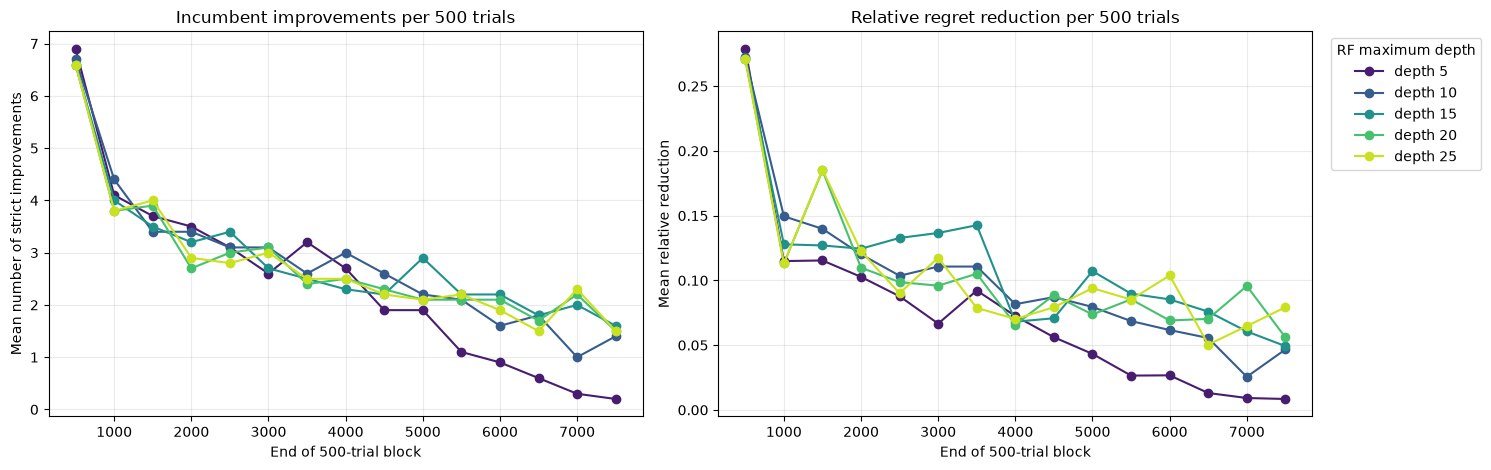

In [8]:
block_rows = []
for (benchmark_seed, depth, smac_seed), best_regret in curves.items():
    for block_end in BLOCK_ENDS:
        start = block_end - BLOCK_SIZE
        baseline = best_regret[0] if start == 0 else best_regret[start - 1]
        segment = best_regret[start:block_end]
        path_with_baseline = np.concatenate(([baseline], segment))
        absolute_reduction = float(baseline - segment[-1])
        relative_reduction = absolute_reduction / max(abs(float(baseline)), 1e-12)
        block_rows.append(
            {
                "benchmark_seed": benchmark_seed,
                "depth": depth,
                "smac_seed": smac_seed,
                "block_end": block_end,
                "improvement_count": int(np.count_nonzero(np.diff(path_with_baseline) < 0)),
                "relative_regret_reduction": relative_reduction,
            }
        )

block_metrics = pd.DataFrame(block_rows)
block_summary = (
    block_metrics.groupby(["depth", "block_end"])
    .agg(
        improvement_count_mean=("improvement_count", "mean"),
        improvement_count_std=("improvement_count", "std"),
        relative_reduction_mean=("relative_regret_reduction", "mean"),
        relative_reduction_std=("relative_regret_reduction", "std"),
    )
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(15, 4.8), sharex=True)
for depth in DEPTHS:
    depth_summary = block_summary[block_summary["depth"] == depth]
    axes[0].plot(
        depth_summary["block_end"],
        depth_summary["improvement_count_mean"],
        marker="o",
        color=COLORS[depth],
        label=f"depth {depth}",
    )
    axes[1].plot(
        depth_summary["block_end"],
        depth_summary["relative_reduction_mean"],
        marker="o",
        color=COLORS[depth],
        label=f"depth {depth}",
    )
axes[0].set(
    title="Incumbent improvements per 500 trials",
    xlabel="End of 500-trial block",
    ylabel="Mean number of strict improvements",
)
axes[1].set(
    title="Relative regret reduction per 500 trials",
    xlabel="End of 500-trial block",
    ylabel="Mean relative reduction",
)
for axis in axes:
    axis.grid(alpha=0.25)
axes[1].legend(title="RF maximum depth", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
plt.show()

## Improvement-signal tables

The first two tables contain the plotted block means in exact numerical form. The final table summarizes how often each run improved, the trial of its last improvement, and the number of trials remaining after that improvement. Large `trials_since_last_improvement` values indicate sustained stagnation, whereas a large total improvement count with recent improvements argues against switching merely because a fixed trial threshold was reached.

In [9]:
improvement_count_table = (
    block_summary.pivot(index="depth", columns="block_end", values="improvement_count_mean")
    .reindex(index=DEPTHS, columns=BLOCK_ENDS)
)
relative_reduction_table = (
    block_summary.pivot(index="depth", columns="block_end", values="relative_reduction_mean")
    .reindex(index=DEPTHS, columns=BLOCK_ENDS)
)

last_improvement_rows = []
for (benchmark_seed, depth, smac_seed), best_regret in curves.items():
    improvement_trials = np.flatnonzero(np.diff(best_regret) < 0) + 2
    last_improvement_trial = int(improvement_trials[-1]) if len(improvement_trials) else 1
    last_improvement_rows.append(
        {
            "benchmark_seed": benchmark_seed,
            "depth": depth,
            "smac_seed": smac_seed,
            "improvement_count": int(len(improvement_trials)),
            "last_improvement_trial": last_improvement_trial,
            "trials_since_last_improvement": N_TRIALS - last_improvement_trial,
        }
    )
last_improvements = pd.DataFrame(last_improvement_rows)
stagnation_summary = (
    last_improvements.groupby("depth")
    .agg(
        improvements_mean=("improvement_count", "mean"),
        improvements_std=("improvement_count", "std"),
        last_improvement_median=("last_improvement_trial", "median"),
        last_improvement_min=("last_improvement_trial", "min"),
        last_improvement_max=("last_improvement_trial", "max"),
        trials_since_last_median=("trials_since_last_improvement", "median"),
        trials_since_last_max=("trials_since_last_improvement", "max"),
    )
)

display(improvement_count_table.style.format(precision=1).set_caption("Mean strict improvements in each 500-trial block"))
display(relative_reduction_table.style.format(precision=4).set_caption("Mean relative regret reduction in each 500-trial block"))
display(stagnation_summary.style.format(precision=1).set_caption("Whole-run improvement and stagnation summary"))

block_end,500,1000,1500,2000,2500,3000,3500,4000,4500,5000,5500,6000,6500,7000,7500
depth,,,,,,,,,,,,,,,
5,6.9,4.1,3.7,3.5,3.1,2.6,3.2,2.7,1.9,1.9,1.1,0.9,0.6,0.3,0.2
10,6.7,4.4,3.4,3.4,3.1,3.1,2.6,3.0,2.6,2.2,2.1,1.6,1.8,1.0,1.4
15,6.6,4.0,3.5,3.2,3.4,2.7,2.5,2.3,2.2,2.9,2.2,2.2,1.8,2.0,1.6
20,6.6,3.8,3.9,2.7,3.0,3.1,2.4,2.5,2.3,2.1,2.1,2.1,1.7,2.2,1.5
25,6.6,3.8,4.0,2.9,2.8,3.0,2.5,2.5,2.2,2.1,2.2,1.9,1.5,2.3,1.5


block_end,500,1000,1500,2000,2500,3000,3500,4000,4500,5000,5500,6000,6500,7000,7500
depth,,,,,,,,,,,,,,,
5,0.2788,0.1149,0.1154,0.1027,0.0877,0.0666,0.0922,0.0725,0.0561,0.0433,0.0265,0.0267,0.0131,0.0092,0.0084
10,0.2722,0.1495,0.1398,0.1201,0.1036,0.1107,0.1107,0.0816,0.0871,0.0795,0.0686,0.0617,0.0555,0.0256,0.0467
15,0.2710,0.1278,0.1270,0.1245,0.1328,0.1366,0.1426,0.0681,0.0708,0.1072,0.0897,0.0853,0.0759,0.0606,0.0493
20,0.2710,0.1131,0.1849,0.1098,0.0987,0.0959,0.1051,0.0659,0.0886,0.0737,0.0854,0.0691,0.0703,0.0957,0.0560
25,0.2710,0.1131,0.1854,0.1225,0.0901,0.1175,0.0787,0.0702,0.0793,0.0940,0.0852,0.1038,0.0504,0.0647,0.0793


,improvements_mean,improvements_std,last_improvement_median,last_improvement_min,last_improvement_max,trials_since_last_median,trials_since_last_max
depth,,,,,,,
5,36.7,8.5,5862.5,4610,7076,1637.5,2890
10,42.4,6.3,7400.5,5678,7488,99.5,1822
15,43.1,5.2,7393.5,6908,7496,106.5,592
20,42.0,5.9,7287.0,6943,7497,213.0,557
25,41.8,6.4,7312.0,6809,7477,188.0,691


## Interpretation checklist

Use the plots and tables together rather than selecting a depth from the pooled final mean alone:

1. Check whether a depth performs consistently on both O1 benchmark seeds.
2. Compare early checkpoint winners with the 7,500-trial winners to identify depth-dependent phases.
3. Look for improvement signals that change *before* the preferred depth changes. Those signals are plausible inputs to a runtime policy.
4. Avoid treating a short no-improvement window as sufficient evidence of stagnation; compare it with the empirical block counts and last-improvement distribution.
5. Validate any adaptive rule on additional benchmark seeds instead of tuning and evaluating it on these same two landscapes.